# RoverAI: Sistema Inteligente de Decisão Autônoma para Exploração Planetária

## GS 2026.1 — Inteligência Artificial e Generative AI

Este notebook desenvolve um protótipo de Inteligência Artificial para apoiar a tomada de decisão de um rover planetário em uma missão de exploração.  
A ideia é simular dados de sensores e telemetria, treinar modelos de classificação e comparar o comportamento de uma **Árvore de Decisão** com uma **Rede Neural Artificial MLP**.

Também foi incluída uma etapa complementar de **Regressão Linear** para prever o consumo de energia do rover e uma etapa opcional de **Visão Computacional** com detecção de bordas em uma imagem simulada de terreno.

## 1. Contexto do problema

Em uma missão planetária, o rover precisa operar em um ambiente desconhecido, com obstáculos, variações de terreno, risco de superaquecimento, perda de comunicação e limitação de bateria.

Como a comunicação com a Terra pode ser lenta ou instável, o rover precisa tomar decisões de forma autônoma. Neste projeto, a IA recebe dados simulados de sensores e classifica qual ação deve ser executada:

- `seguir_em_frente`
- `reduzir_velocidade`
- `desviar_direita`
- `desviar_esquerda`
- `parar`
- `retornar_base`
- `modo_seguro`

In [1]:
# Importação das bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Configuração pra repetir o resultado
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

print('Bibliotecas carregadas com sucesso.')
print(f'RANDOM_STATE definido como {RANDOM_STATE}.')
print('Gerador rng criado com np.random.default_rng(RANDOM_STATE).')

Bibliotecas carregadas com sucesso.
RANDOM_STATE definido como 42.
Gerador rng criado com np.random.default_rng(RANDOM_STATE).


## 2. Base de dados simulada

A base foi **gerada com Python**, conforme permitido no enunciado do projeto. Ela não foi retirada de uma base real externa: trata-se de uma base sintética, criada para simular situações operacionais enfrentadas por um rover durante uma missão planetária.

Cada linha representa uma situação da missão, e cada coluna representa uma leitura de sensor, uma condição operacional ou a ação esperada do rover. A variável alvo da classificação é `acao_rover`, isto é, a decisão que os modelos de IA deverão aprender a prever.

Para manter coerência com o problema, os registros foram gerados por faixas de valores diferentes para cada ação. Por exemplo: situações com obstáculo muito próximo tendem a gerar `parar`; bateria muito baixa tende a gerar `retornar_base`; temperatura alta, vibração elevada ou sinal de comunicação muito baixo tendem a gerar `modo_seguro`; e condições estáveis tendem a gerar `seguir_em_frente`.

### Variáveis utilizadas

| Variável | Significado | Unidade / Tipo |
|---|---|---|
| `distancia_obstaculo_m` | Distância até o obstáculo mais próximo | metros |
| `inclinacao_terreno_graus` | Inclinação do terreno | graus |
| `bateria_percentual` | Nível de bateria do rover | % |
| `temperatura_sistema_c` | Temperatura do sistema/motor | °C |
| `vibracao_ms2` | Vibração percebida pelo rover | m/s² |
| `sinal_comunicacao_percentual` | Qualidade do sinal de comunicação | % |
| `luminosidade_lux` | Intensidade de luz do ambiente | lux |
| `velocidade_atual_ms` | Velocidade atual do rover | m/s |
| `poeira_percentual` | Estimativa de poeira no ambiente | % |
| `tipo_terreno` | Tipo do terreno identificado | plano, rochoso, arenoso ou cratera |
| `consumo_energia_wh` | Consumo estimado de energia | Wh |
| `acao_rover` | Ação esperada do rover | variável alvo da classificação |

A base possui **300 registros**

In [2]:
def gerar_intervalo(n, dist, inc, bat, temp, vib, sinal, lum, vel, poeira, acao):
    # Gera registros coerentes para uma ação específica do rover
    return pd.DataFrame({
        'distancia_obstaculo_m': np.round(rng.uniform(*dist, n), 2),
        'inclinacao_terreno_graus': np.round(rng.uniform(*inc, n), 2),
        'bateria_percentual': np.round(rng.uniform(*bat, n), 2),
        'temperatura_sistema_c': np.round(rng.uniform(*temp, n), 2),
        'vibracao_ms2': np.round(rng.uniform(*vib, n), 2),
        'sinal_comunicacao_percentual': np.round(rng.uniform(*sinal, n), 2),
        'luminosidade_lux': np.round(rng.uniform(*lum, n), 2),
        'velocidade_atual_ms': np.round(rng.uniform(*vel, n), 2),
        'poeira_percentual': np.round(rng.uniform(*poeira, n), 2),
        'acao_rover': acao
    })

# Intervalos definidos com coerência física para cada ação do rover
configuracoes = {
    'seguir_em_frente': ((7, 20), (0, 12), (45, 100), (22, 62), (0.1, 2.2), (70, 100), (250, 1000), (0.6, 1.8), (0, 45)),
    'reduzir_velocidade': ((4.5, 16), (18, 32), (20, 65), (60, 82), (3.2, 6.8), (25, 75), (80, 900), (0.4, 1.5), (25, 85)),
    'desviar_direita': ((1.4, 4.4), (3, 22), (25, 100), (22, 74), (0.4, 4.2), (50, 100), (520, 1000), (0.3, 1.2), (0, 55)),
    'desviar_esquerda': ((1.4, 4.4), (3, 22), (25, 100), (22, 74), (0.4, 4.2), (50, 100), (0, 500), (0.3, 1.2), (55, 100)),
    'parar': ((0.2, 1.2), (0, 18), (20, 100), (22, 70), (0.1, 3.5), (45, 100), (0, 1000), (0.1, 0.9), (0, 100)),
    'retornar_base': ((4, 20), (0, 18), (5, 18), (22, 68), (0.1, 3.2), (45, 100), (0, 1000), (0.2, 1.3), (0, 75)),
    'modo_seguro': ((0.2, 20), (0, 35), (5, 100), (84, 100), (6.8, 10), (0, 20), (0, 1000), (0.1, 1.0), (0, 100))
}

# Geração de exatamente 300 registros no total, distribuídos entre as ações do rover
quantidades_por_acao = {
    'seguir_em_frente': 45,
    'reduzir_velocidade': 45,
    'desviar_direita': 45,
    'desviar_esquerda': 45,
    'parar': 40,
    'retornar_base': 40,
    'modo_seguro': 40
}

frames = []
for acao, parametros in configuracoes.items():
    n = quantidades_por_acao[acao]
    frames.append(gerar_intervalo(n, *parametros, acao))

df = pd.concat(frames, ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Criação de uma variável categórica coerente com inclinação, vibração, poeira e obstáculo
def definir_tipo_terreno(linha):
    if linha['inclinacao_terreno_graus'] > 26 or linha['vibracao_ms2'] > 6.5:
        return 'rochoso'
    elif linha['distancia_obstaculo_m'] < 3 and linha['inclinacao_terreno_graus'] > 15:
        return 'cratera'
    elif linha['poeira_percentual'] > 65 and linha['luminosidade_lux'] < 450:
        return 'arenoso'
    else:
        return 'plano'

df['tipo_terreno'] = df.apply(definir_tipo_terreno, axis=1)

# Variável numérica para a etapa de Regressão Linear: consumo de energia estimado
rng_reg = np.random.default_rng(101)
df['consumo_energia_wh'] = np.round(
    6
    + 0.22 * df['inclinacao_terreno_graus']
    + 0.08 * df['temperatura_sistema_c']
    + 1.65 * df['vibracao_ms2']
    + 1.20 * df['velocidade_atual_ms']
    + 0.04 * df['poeira_percentual']
    + 0.015 * (100 - df['sinal_comunicacao_percentual'])
    + rng_reg.normal(0, 1.2, len(df)),
    2
)

# Inserção controlada de alguns NaNs para simular falhas/corrupções de sensores
for col in ['temperatura_sistema_c', 'vibracao_ms2', 'sinal_comunicacao_percentual']:
    indices = rng_reg.choice(df.index, size=int(0.03 * len(df)), replace=False)
    df.loc[indices, col] = np.nan

# Salvando a base simulada em CSV
df.to_csv('roverai_base_simulada.csv', index=False)

print(f'Tamanho da base: {df.shape[0]} linhas e {df.shape[1]} colunas')
print('Distribuição planejada das ações:')
display(df['acao_rover'].value_counts().sort_index())
df.head()


Tamanho da base: 300 linhas e 12 colunas
Distribuição planejada das ações:


,count
acao_rover,
desviar_direita,45
desviar_esquerda,45
modo_seguro,40
parar,40
reduzir_velocidade,45
retornar_base,40
seguir_em_frente,45


,distancia_obstaculo_m,inclinacao_terreno_graus,bateria_percentual,temperatura_sistema_c,vibracao_ms2,sinal_comunicacao_percentual,luminosidade_lux,velocidade_atual_ms,poeira_percentual,acao_rover,tipo_terreno,consumo_energia_wh
0,0.40,5.18,65.08,26.32,2.46,96.76,749.17,0.39,15.36,parar,plano,13.49
1,17.28,34.55,11.52,NaN,9.81,19.40,334.36,0.60,89.52,modo_seguro,rochoso,40.63
2,1.99,4.96,25.41,29.26,3.60,71.89,185.46,0.98,97.72,desviar_esquerda,arenoso,21.60
3,12.86,8.46,97.90,40.94,0.65,97.99,888.35,1.62,40.43,seguir_em_frente,plano,16.69
4,5.14,7.58,16.12,50.20,2.58,48.24,949.85,1.13,13.55,retornar_base,plano,18.24


Distribuição da variável alvo:


,count
acao_rover,
desviar_direita,45
desviar_esquerda,45
modo_seguro,40
parar,40
reduzir_velocidade,45
retornar_base,40
seguir_em_frente,45


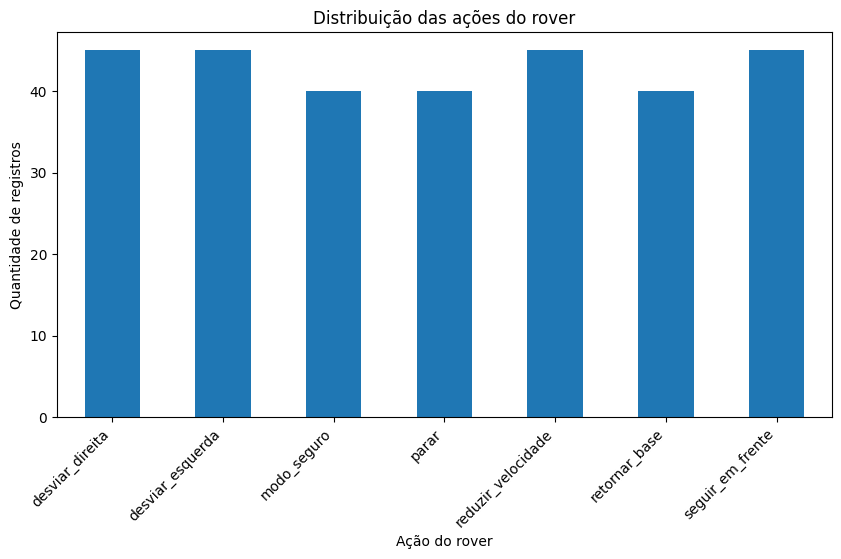

In [3]:
# Distribuição das ações do rover
print('Distribuição da variável alvo:')
distribuicao_acoes = df['acao_rover'].value_counts().sort_index()
display(distribuicao_acoes)

plt.figure(figsize=(10, 5))
distribuicao_acoes.plot(kind='bar')
plt.title('Distribuição das ações do rover')
plt.xlabel('Ação do rover')
plt.ylabel('Quantidade de registros')
plt.xticks(rotation=45, ha='right')
plt.show()

## 3. Organização e tratamento dos dados

Nesta etapa, os dados são preparados para os modelos de Machine Learning.

Procedimentos realizados:

1. verificação de valores ausentes;
2. preenchimento de valores ausentes numéricos pela média da respectiva coluna;
3. transformação da variável categórica `tipo_terreno` em colunas numéricas com `get_dummies`;
4. separação entre variáveis de entrada `X` e alvo `y`;
5. codificação da variável alvo com `LabelEncoder`;
6. divisão entre treino e teste.

In [4]:
# Verificação de valores ausentes antes do tratamento
print('Valores ausentes antes do tratamento:')
display(df.isna().sum())

# Cópia para tratamento
df_modelo = df.copy()

# Preenchimento de valores ausentes numéricos com a média
colunas_numericas = df_modelo.select_dtypes(include=[np.number]).columns
for col in colunas_numericas:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].mean())

print('Valores ausentes depois do tratamento:')
display(df_modelo.isna().sum())

Valores ausentes antes do tratamento:


,0
distancia_obstaculo_m,0
inclinacao_terreno_graus,0
bateria_percentual,0
temperatura_sistema_c,9
vibracao_ms2,9
sinal_comunicacao_percentual,9
luminosidade_lux,0
velocidade_atual_ms,0
poeira_percentual,0
acao_rover,0


Valores ausentes depois do tratamento:


,0
distancia_obstaculo_m,0
inclinacao_terreno_graus,0
bateria_percentual,0
temperatura_sistema_c,0
vibracao_ms2,0
sinal_comunicacao_percentual,0
luminosidade_lux,0
velocidade_atual_ms,0
poeira_percentual,0
acao_rover,0


In [5]:
# Separação das variáveis de classificação
# A coluna consumo_energia_wh fica fora da classificação porque será usada como alvo na regressão linear complementar
X_raw = df_modelo.drop(columns=['acao_rover', 'consumo_energia_wh'])
y_texto = df_modelo['acao_rover']

X = pd.get_dummies(X_raw, columns=['tipo_terreno'], dtype=int)

# Codificação da variável alvo
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_texto)

print('Classes codificadas:')
for codigo, classe in enumerate(label_encoder.classes_):
    print(codigo, '->', classe)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Tamanho treino:', X_train.shape)
print('Tamanho teste:', X_test.shape)

Classes codificadas:
0 -> desviar_direita
1 -> desviar_esquerda
2 -> modo_seguro
3 -> parar
4 -> reduzir_velocidade
5 -> retornar_base
6 -> seguir_em_frente
Tamanho treino: (225, 13)
Tamanho teste: (75, 13)


## 4. Modelo 1 — Árvore de Decisão

A Árvore de Decisão foi escolhida porque cria regras interpretáveis, algo importante em sistemas críticos como navegação autônoma.  
O modelo aprende divisões nos dados com base em critérios como o Índice Gini, separando as situações do rover em diferentes ações.

In [6]:
# Treinamento da Árvore de Decisão
modelo_arvore = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    random_state=RANDOM_STATE
)

modelo_arvore.fit(X_train, y_train)
y_pred_arvore = modelo_arvore.predict(X_test)

acuracia_arvore = accuracy_score(y_test, y_pred_arvore)
print(f'Acurácia da Árvore de Decisão: {acuracia_arvore:.4f}')
print()
print('Relatório de classificação - Árvore de Decisão:')
print(classification_report(y_test, y_pred_arvore, target_names=label_encoder.classes_, zero_division=0))

Acurácia da Árvore de Decisão: 0.9867

Relatório de classificação - Árvore de Decisão:
                    precision    recall  f1-score   support

   desviar_direita       1.00      1.00      1.00        11
  desviar_esquerda       1.00      1.00      1.00        11
       modo_seguro       1.00      0.90      0.95        10
             parar       1.00      1.00      1.00        10
reduzir_velocidade       0.92      1.00      0.96        12
     retornar_base       1.00      1.00      1.00        10
  seguir_em_frente       1.00      1.00      1.00        11

          accuracy                           0.99        75
         macro avg       0.99      0.99      0.99        75
      weighted avg       0.99      0.99      0.99        75



<Figure size 900x700 with 0 Axes>

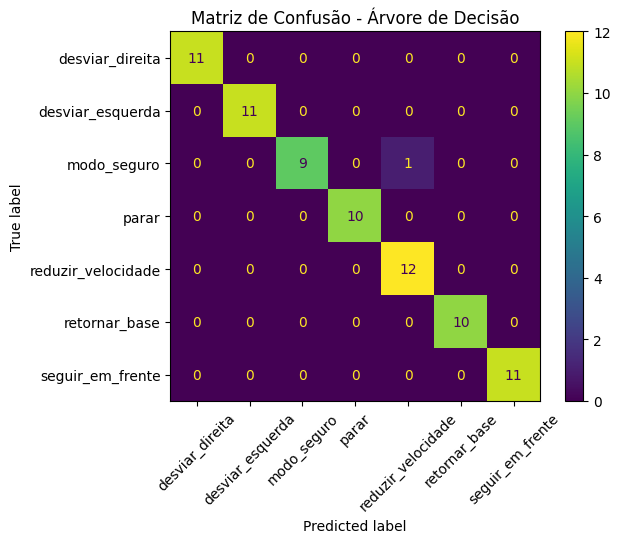

In [7]:
# Matriz de confusão da Árvore de Decisão
matriz_arvore = confusion_matrix(y_test, y_pred_arvore)

plt.figure(figsize=(9, 7))
disp_arvore = ConfusionMatrixDisplay(
    confusion_matrix=matriz_arvore,
    display_labels=label_encoder.classes_
)
disp_arvore.plot(xticks_rotation=45)
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.show()

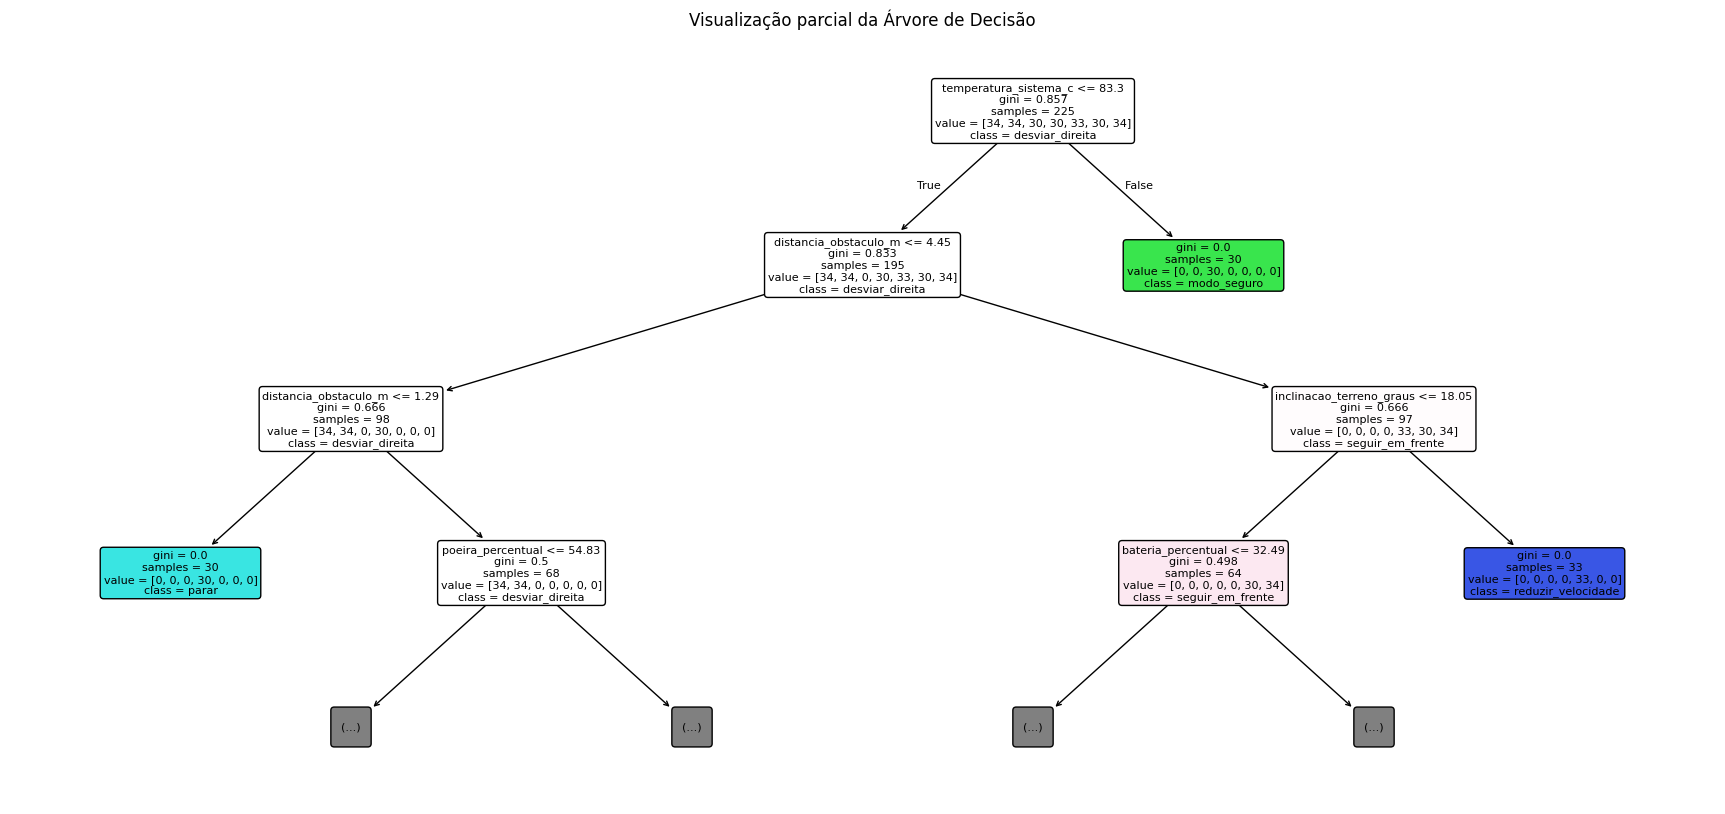

In [8]:
# Visualização simplificada da Árvore de Decisão
plt.figure(figsize=(22, 10))
plot_tree(
    modelo_arvore,
    feature_names=X.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('Visualização parcial da Árvore de Decisão')
plt.show()

Principais variáveis usadas pela Árvore de Decisão:


,variavel,importancia
0,distancia_obstaculo_m,0.331122
8,poeira_percentual,0.176397
1,inclinacao_terreno_graus,0.169665
2,bateria_percentual,0.165373
3,temperatura_sistema_c,0.157443
4,vibracao_ms2,0.000000
5,sinal_comunicacao_percentual,0.000000
6,luminosidade_lux,0.000000
7,velocidade_atual_ms,0.000000
9,tipo_terreno_arenoso,0.000000


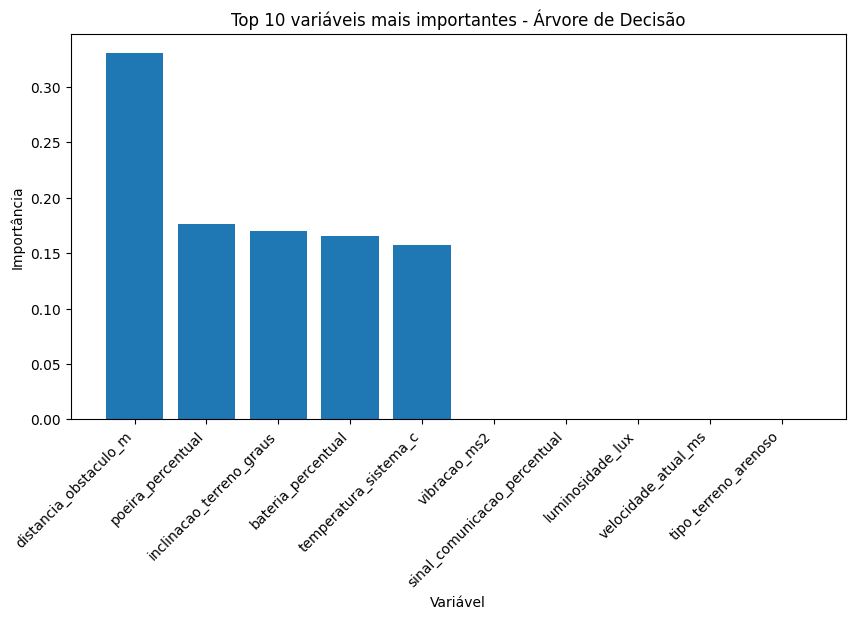

In [9]:
# Importância das variáveis na Árvore de Decisão
importancias = pd.DataFrame({
    'variavel': X.columns,
    'importancia': modelo_arvore.feature_importances_
}).sort_values(by='importancia', ascending=False)

print('Principais variáveis usadas pela Árvore de Decisão:')
display(importancias.head(10))

plt.figure(figsize=(10, 5))
plt.bar(importancias['variavel'].head(10), importancias['importancia'].head(10))
plt.title('Top 10 variáveis mais importantes - Árvore de Decisão')
plt.xlabel('Variável')
plt.ylabel('Importância')
plt.xticks(rotation=45, ha='right')
plt.show()

## 5. Modelo 2 — Rede Neural Artificial MLP

A Rede MLP foi utilizada para resolver o mesmo problema de classificação da Árvore de Decisão: prever a ação mais adequada do rover com base nos dados dos sensores e da telemetria.

Esse modelo segue a ideia de uma arquitetura **feedforward**, em que os dados de entrada passam por camadas de neurônios artificiais até gerar a classificação final. Cada neurônio realiza uma combinação ponderada das entradas, utilizando **pesos**, **bias** e **funções de ativação**, conceitos relacionados ao perceptron e às redes neurais estudadas nas aulas.

Diferentemente da Árvore de Decisão, a MLP é mais sensível à escala dos dados. Por isso, antes do treinamento, as variáveis numéricas foram padronizadas com `StandardScaler`, deixando os atributos em uma escala mais adequada para o processo de aprendizagem da rede neural.

In [10]:
# Padronização dos dados para a MLP
scaler_classificacao = StandardScaler()
X_train_scaled = scaler_classificacao.fit_transform(X_train)
X_test_scaled = scaler_classificacao.transform(X_test)

# Treinamento da MLP
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=1500,
    random_state=RANDOM_STATE
)

modelo_mlp.fit(X_train_scaled, y_train)
y_pred_mlp = modelo_mlp.predict(X_test_scaled)

acuracia_mlp = accuracy_score(y_test, y_pred_mlp)
print(f'Acurácia da MLP: {acuracia_mlp:.4f}')
print(f'Número de iterações da MLP: {modelo_mlp.n_iter_}')
print()
print('Relatório de classificação - MLP:')
print(classification_report(y_test, y_pred_mlp, target_names=label_encoder.classes_, zero_division=0))

Acurácia da MLP: 0.8933
Número de iterações da MLP: 526

Relatório de classificação - MLP:
                    precision    recall  f1-score   support

   desviar_direita       0.79      1.00      0.88        11
  desviar_esquerda       1.00      0.73      0.84        11
       modo_seguro       0.90      0.90      0.90        10
             parar       0.73      0.80      0.76        10
reduzir_velocidade       0.92      0.92      0.92        12
     retornar_base       1.00      0.90      0.95        10
  seguir_em_frente       1.00      1.00      1.00        11

          accuracy                           0.89        75
         macro avg       0.90      0.89      0.89        75
      weighted avg       0.91      0.89      0.89        75



<Figure size 900x700 with 0 Axes>

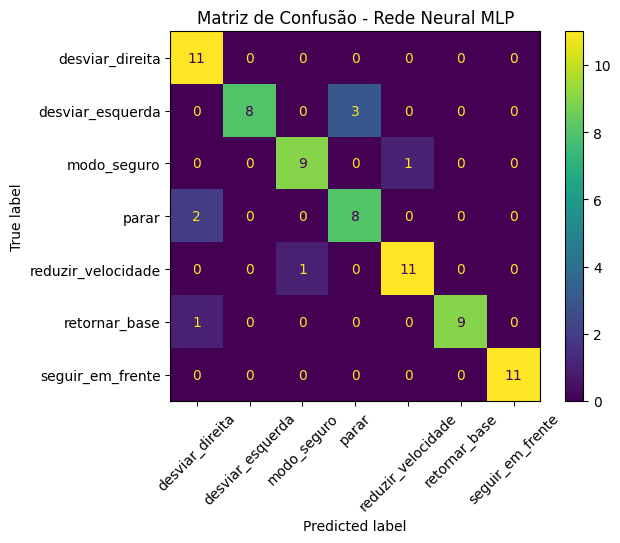

In [11]:
# Matriz de confusão da MLP
matriz_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(9, 7))
disp_mlp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_mlp,
    display_labels=label_encoder.classes_
)
disp_mlp.plot(xticks_rotation=45)
plt.title('Matriz de Confusão - Rede Neural MLP')
plt.show()

## 6. Comparação entre os modelos

A comparação deve considerar não apenas o desempenho, mas também a interpretabilidade e os riscos de uso em um rover autônomo.

- **Árvore de Decisão:** mais fácil de interpretar, pois suas regras podem ser visualizadas. Isso é positivo em sistemas críticos, porque permite entender por que o rover decidiu parar, desviar ou entrar em modo seguro.
- **MLP:** pode aprender padrões mais complexos, mas é menos interpretável. Mesmo com boa acurácia, é mais difícil explicar exatamente qual regra levou à decisão.

In [12]:
comparacao_modelos = pd.DataFrame({
    'Modelo': ['Árvore de Decisão', 'Rede Neural MLP'],
    'Acurácia no teste': [acuracia_arvore, acuracia_mlp],
    'Interpretação': ['Alta: regras e árvore visíveis', 'Baixa/Média: pesos internos difíceis de explicar'],
    'Adequação ao rover': [
        'Boa para decisões auditáveis e sistemas críticos',
        'Boa para padrões complexos, mas exige mais validação'
    ]
})

comparacao_modelos

,Modelo,Acurácia no teste,Interpretação,Adequação ao rover
0,Árvore de Decisão,0.986667,Alta: regras e árvore visíveis,Boa para decisões auditáveis e sistemas críticos
1,Rede Neural MLP,0.893333,Baixa/Média: pesos internos difíceis de explicar,"Boa para padrões complexos, mas exige mais val..."


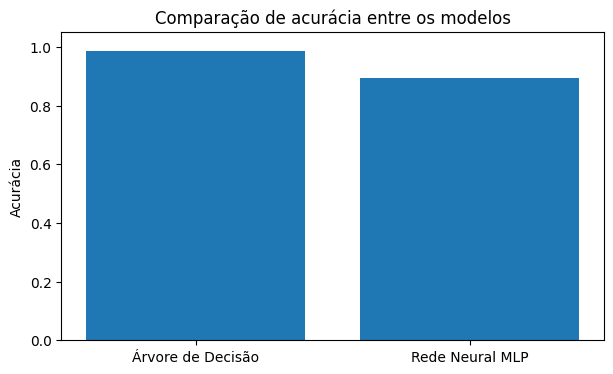

In [13]:
plt.figure(figsize=(7, 4))
plt.bar(comparacao_modelos['Modelo'], comparacao_modelos['Acurácia no teste'])
plt.ylim(0, 1.05)
plt.title('Comparação de acurácia entre os modelos')
plt.ylabel('Acurácia')
plt.show()

### Comentário técnico da comparação

Na base simulada, os dois modelos apresentaram bom desempenho porque os dados foram construídos com regras coerentes. A Árvore de Decisão tende a ser a melhor escolha quando a prioridade é explicar as decisões do rover, principalmente em situações críticas como obstáculo próximo, bateria baixa ou superaquecimento.

A MLP também é útil, especialmente se o problema real tiver padrões mais complexos e não lineares. Porém, em uma missão real, uma rede neural precisaria passar por validação rigorosa, pois seus erros são menos transparentes do que os erros de uma árvore.


## 7. Etapa complementar — Regressão Linear

Além da classificação da ação do rover, foi criada uma tarefa de regressão para prever uma variável numérica relevante: o **consumo de energia em Wh**.

Essa previsão é útil porque o rover pode usar a estimativa de consumo para planejar deslocamentos, economizar bateria e decidir quando retornar à base.

In [14]:
# Preparação dos dados para regressão linear
X_reg = X.copy()
y_reg = df_modelo['consumo_energia_wh']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=RANDOM_STATE
)

# Padronização para a regressão
scaler_regressao = StandardScaler()
X_train_reg_scaled = scaler_regressao.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_regressao.transform(X_test_reg)

# Treinamento do modelo de Regressão Linear
modelo_regressao = LinearRegression()
modelo_regressao.fit(X_train_reg_scaled, y_train_reg)

# Predição e avaliação numérica
pred_reg = modelo_regressao.predict(X_test_reg_scaled)

mae_reg = mean_absolute_error(y_test_reg, pred_reg)
rmse_reg = np.sqrt(mean_squared_error(y_test_reg, pred_reg))
r2_reg = r2_score(y_test_reg, pred_reg)

metricas_regressao = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R²'],
    'Valor': [mae_reg, rmse_reg, r2_reg],
    'Interpretação': [
        'Erro médio absoluto entre consumo real e previsto, em Wh',
        'Raiz do erro quadrático médio; penaliza erros maiores, em Wh',
        'Proporção da variação do consumo explicada pelo modelo'
    ]
})

print('Métricas da Regressão Linear complementar:')
print(f'MAE: {mae_reg:.4f} Wh')
print(f'RMSE: {rmse_reg:.4f} Wh')
print(f'R²: {r2_reg:.4f}')
display(metricas_regressao)


Métricas da Regressão Linear complementar:
MAE: 1.1495 Wh
RMSE: 1.4506 Wh
R²: 0.9692


,Métrica,Valor,Interpretação
0,MAE,1.149531,Erro médio absoluto entre consumo real e previ...
1,RMSE,1.450559,Raiz do erro quadrático médio; penaliza erros ...
2,R²,0.969243,Proporção da variação do consumo explicada pel...


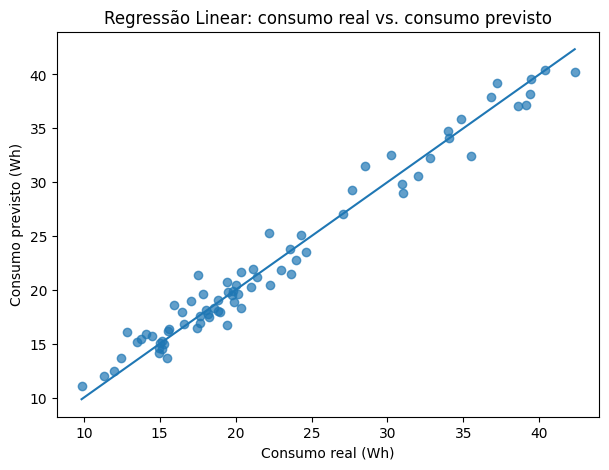

In [15]:
# Visualização: valores reais vs. previstos
plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, pred_reg, alpha=0.7)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()])
plt.title('Regressão Linear: consumo real vs. consumo previsto')
plt.xlabel('Consumo real (Wh)')
plt.ylabel('Consumo previsto (Wh)')
plt.show()

## 8. Testes com novos cenários

Agora serão criados cenários novos, simulando situações específicas da missão:

1. obstáculo muito próximo;
2. bateria baixa;
3. terreno inclinado;
4. superaquecimento;
5. perda parcial de comunicação;
6. situação normal de operação;
7. desvio à direita;
8. desvio à esquerda.

Os cenários serão avaliados pela Árvore de Decisão, pela MLP e também pela Regressão Linear para estimar o consumo de energia.

In [16]:
cenarios = pd.DataFrame([
    {'cenario': 'Obstáculo muito próximo', 'distancia_obstaculo_m': 0.6, 'inclinacao_terreno_graus': 8, 'bateria_percentual': 80, 'temperatura_sistema_c': 45, 'vibracao_ms2': 1.2, 'sinal_comunicacao_percentual': 90, 'luminosidade_lux': 600, 'velocidade_atual_ms': 0.7, 'poeira_percentual': 20, 'tipo_terreno': 'plano'},
    {'cenario': 'Bateria baixa', 'distancia_obstaculo_m': 12, 'inclinacao_terreno_graus': 5, 'bateria_percentual': 9, 'temperatura_sistema_c': 40, 'vibracao_ms2': 1.0, 'sinal_comunicacao_percentual': 85, 'luminosidade_lux': 500, 'velocidade_atual_ms': 0.8, 'poeira_percentual': 20, 'tipo_terreno': 'plano'},
    {'cenario': 'Terreno inclinado', 'distancia_obstaculo_m': 10, 'inclinacao_terreno_graus': 30, 'bateria_percentual': 55, 'temperatura_sistema_c': 64, 'vibracao_ms2': 4.5, 'sinal_comunicacao_percentual': 65, 'luminosidade_lux': 350, 'velocidade_atual_ms': 1.0, 'poeira_percentual': 45, 'tipo_terreno': 'rochoso'},
    {'cenario': 'Superaquecimento', 'distancia_obstaculo_m': 8, 'inclinacao_terreno_graus': 12, 'bateria_percentual': 60, 'temperatura_sistema_c': 92, 'vibracao_ms2': 3.0, 'sinal_comunicacao_percentual': 70, 'luminosidade_lux': 400, 'velocidade_atual_ms': 0.6, 'poeira_percentual': 30, 'tipo_terreno': 'plano'},
    {'cenario': 'Perda parcial de comunicação', 'distancia_obstaculo_m': 9, 'inclinacao_terreno_graus': 10, 'bateria_percentual': 50, 'temperatura_sistema_c': 48, 'vibracao_ms2': 1.5, 'sinal_comunicacao_percentual': 18, 'luminosidade_lux': 450, 'velocidade_atual_ms': 0.7, 'poeira_percentual': 35, 'tipo_terreno': 'plano'},
    {'cenario': 'Situação normal de operação', 'distancia_obstaculo_m': 15, 'inclinacao_terreno_graus': 4, 'bateria_percentual': 85, 'temperatura_sistema_c': 38, 'vibracao_ms2': 0.8, 'sinal_comunicacao_percentual': 95, 'luminosidade_lux': 700, 'velocidade_atual_ms': 1.2, 'poeira_percentual': 15, 'tipo_terreno': 'plano'},
    {'cenario': 'Obstáculo com espaço à direita', 'distancia_obstaculo_m': 2.5, 'inclinacao_terreno_graus': 10, 'bateria_percentual': 75, 'temperatura_sistema_c': 45, 'vibracao_ms2': 1.7, 'sinal_comunicacao_percentual': 80, 'luminosidade_lux': 850, 'velocidade_atual_ms': 0.6, 'poeira_percentual': 20, 'tipo_terreno': 'plano'},
    {'cenario': 'Obstáculo com poeira intensa', 'distancia_obstaculo_m': 2.4, 'inclinacao_terreno_graus': 11, 'bateria_percentual': 70, 'temperatura_sistema_c': 47, 'vibracao_ms2': 1.9, 'sinal_comunicacao_percentual': 82, 'luminosidade_lux': 200, 'velocidade_atual_ms': 0.5, 'poeira_percentual': 85, 'tipo_terreno': 'arenoso'}
])

# Ação esperada pelo grupo para cada cenário, definida por regra lógica do domínio
# Essa coluna não é usada no treinamento,serve apenas para discutir se a predição faz sentido
acao_esperada_por_cenario = {
    'Obstáculo muito próximo': 'parar',
    'Bateria baixa': 'retornar_base',
    'Terreno inclinado': 'reduzir_velocidade',
    'Superaquecimento': 'modo_seguro',
    'Perda parcial de comunicação': 'modo_seguro',
    'Situação normal de operação': 'seguir_em_frente',
    'Obstáculo com espaço à direita': 'desviar_direita',
    'Obstáculo com poeira intensa': 'desviar_esquerda'
}

comentario_por_cenario = {
    'Obstáculo muito próximo': 'Com obstáculo a 0,6 m, seguir em frente seria arriscado; parar é uma decisão segura.',
    'Bateria baixa': 'Com bateria em 9%, a prioridade é preservar energia e retornar à base.',
    'Terreno inclinado': 'Inclinação de 30 graus e vibração alta indicam risco mecânico; reduzir velocidade é coerente.',
    'Superaquecimento': 'Temperatura de 92 °C representa condição crítica; modo seguro protege o sistema.',
    'Perda parcial de comunicação': 'Sinal de 18% limita o controle remoto; modo seguro reduz o risco da missão.',
    'Situação normal de operação': 'Sensores em faixa segura indicam que o rover pode continuar avançando.',
    'Obstáculo com espaço à direita': 'Obstáculo próximo com boa luminosidade e baixa poeira favorece desvio à direita.',
    'Obstáculo com poeira intensa': 'Obstáculo próximo com poeira intensa e baixa luminosidade favorece desvio mais conservador à esquerda.'
}

# Preparação dos cenários no mesmo formato usado no treinamento
X_cenarios_raw = cenarios.drop(columns=['cenario'])
X_cenarios = pd.get_dummies(X_cenarios_raw, columns=['tipo_terreno'], dtype=int)
X_cenarios = X_cenarios.reindex(columns=X.columns, fill_value=0)

# Predição com Árvore de Decisão
pred_cenarios_arvore_cod = modelo_arvore.predict(X_cenarios)
pred_cenarios_arvore = label_encoder.inverse_transform(pred_cenarios_arvore_cod)

# Predição com MLP
X_cenarios_scaled = scaler_classificacao.transform(X_cenarios)
pred_cenarios_mlp_cod = modelo_mlp.predict(X_cenarios_scaled)
pred_cenarios_mlp = label_encoder.inverse_transform(pred_cenarios_mlp_cod)

# Predição do consumo de energia pela Regressão Linear
X_cenarios_reg_scaled = scaler_regressao.transform(X_cenarios)
pred_consumo_cenarios = modelo_regressao.predict(X_cenarios_reg_scaled)

resultado_cenarios = cenarios[['cenario']].copy()
resultado_cenarios['acao_esperada_pela_regra'] = resultado_cenarios['cenario'].map(acao_esperada_por_cenario)
resultado_cenarios['decisao_arvore'] = pred_cenarios_arvore
resultado_cenarios['coerencia_arvore'] = np.where(
    resultado_cenarios['decisao_arvore'] == resultado_cenarios['acao_esperada_pela_regra'],
    'Coerente',
    'Divergente'
)
resultado_cenarios['decisao_mlp'] = pred_cenarios_mlp
resultado_cenarios['coerencia_mlp'] = np.where(
    resultado_cenarios['decisao_mlp'] == resultado_cenarios['acao_esperada_pela_regra'],
    'Coerente',
    'Divergente'
)
resultado_cenarios['consumo_previsto_wh'] = np.round(pred_consumo_cenarios, 2)
resultado_cenarios['comentario_tecnico'] = resultado_cenarios['cenario'].map(comentario_por_cenario)

pd.set_option('display.max_colwidth', 140)
resultado_cenarios


,cenario,acao_esperada_pela_regra,decisao_arvore,coerencia_arvore,decisao_mlp,coerencia_mlp,consumo_previsto_wh,comentario_tecnico
0,Obstáculo muito próximo,parar,parar,Coerente,parar,Coerente,15.08,"Com obstáculo a 0,6 m, seguir em frente seria arriscado; parar é uma decisão segura."
1,Bateria baixa,retornar_base,retornar_base,Coerente,retornar_base,Coerente,13.69,"Com bateria em 9%, a prioridade é preservar energia e retornar à base."
2,Terreno inclinado,reduzir_velocidade,reduzir_velocidade,Coerente,reduzir_velocidade,Coerente,29.46,Inclinação de 30 graus e vibração alta indicam risco mecânico; reduzir velocidade é coerente.
3,Superaquecimento,modo_seguro,modo_seguro,Coerente,reduzir_velocidade,Divergente,23.04,Temperatura de 92 °C representa condição crítica; modo seguro protege o sistema.
4,Perda parcial de comunicação,modo_seguro,seguir_em_frente,Divergente,reduzir_velocidade,Divergente,18.54,Sinal de 18% limita o controle remoto; modo seguro reduz o risco da missão.
5,Situação normal de operação,seguir_em_frente,seguir_em_frente,Coerente,seguir_em_frente,Coerente,13.13,Sensores em faixa segura indicam que o rover pode continuar avançando.
6,Obstáculo com espaço à direita,desviar_direita,desviar_direita,Coerente,desviar_direita,Coerente,16.31,Obstáculo próximo com boa luminosidade e baixa poeira favorece desvio à direita.
7,Obstáculo com poeira intensa,desviar_esquerda,desviar_esquerda,Coerente,desviar_esquerda,Coerente,19.45,Obstáculo próximo com poeira intensa e baixa luminosidade favorece desvio mais conservador à esquerda.


## Análise dos novos cenários

A tabela acima compara a decisão prevista pelos modelos com uma ação esperada pela regra lógica do domínio. Essa ação esperada não foi usada como entrada dos modelos; ela serve apenas para avaliar se a resposta é coerente com o contexto operacional do rover.

A decisão foi considerada coerente quando respeitou os principais riscos da missão. Por exemplo, um obstáculo muito próximo deveria levar o rover a parar ou desviar; bateria muito baixa deveria levar a `retornar_base`; superaquecimento ou sinal de comunicação muito baixo deveriam levar a `modo_seguro`; terreno inclinado ou vibração elevada deveriam levar a `reduzir_velocidade`; e condições normais deveriam levar a `seguir_em_frente`.

Quando a Árvore de Decisão e a MLP apresentaram decisões diferentes, a análise considerou não apenas a previsão em si, mas também a interpretabilidade do modelo. Em sistemas críticos, a Árvore de Decisão tende a ser mais fácil de justificar, pois suas regras podem ser visualizadas e auditadas. Já a MLP pode apresentar bom desempenho, mas é menos transparente, pois sua decisão depende de pesos internos e camadas ocultas.


## 9. Etapa opcional — Visão Computacional

Esta etapa é um diferencial do projeto.  
Foi criada uma imagem simulada de um terreno planetário com obstáculos circulares e linhas de relevo. Em seguida, foi aplicado o detector de bordas **Canny**, técnica estudada na aula de Visão Computacional.

Essa etapa não substitui os modelos de classificação, mas mostra como imagens poderiam complementar os sensores do rover.

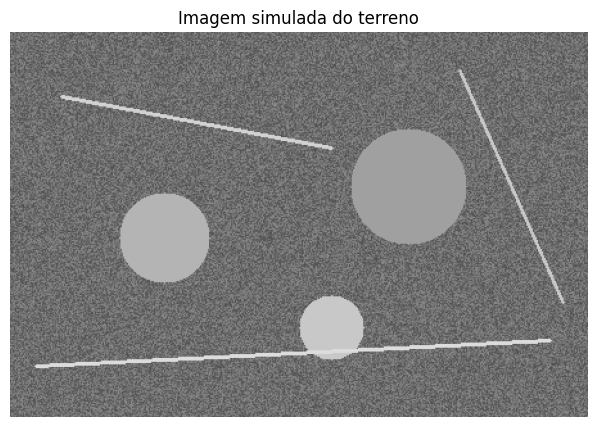

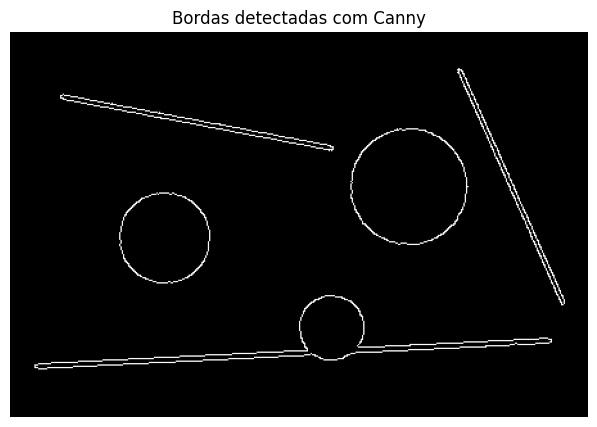

In [17]:
# Visão Computacional opcional com imagem sintética
try:
    import cv2

    # Imagem sintética do terreno
    img = np.zeros((300, 450, 3), dtype=np.uint8)
    img[:] = (80, 80, 80)

    # Ruído para simular textura do solo
    ruido = rng.integers(0, 60, size=(300, 450, 1), dtype=np.uint8)
    img = np.clip(img + ruido, 0, 255).astype(np.uint8)

    # Obstáculos circulares simulados
    cv2.circle(img, (120, 160), 35, (180, 180, 180), -1)
    cv2.circle(img, (310, 120), 45, (160, 160, 160), -1)
    cv2.circle(img, (250, 230), 25, (200, 200, 200), -1)

    # Linhas simulando rachaduras/relevo do terreno
    cv2.line(img, (20, 260), (420, 240), (220, 220, 220), 2)
    cv2.line(img, (40, 50), (250, 90), (210, 210, 210), 2)
    cv2.line(img, (350, 30), (430, 210), (200, 200, 200), 2)

    # Conversão para escala de cinza, suavização e detecção de bordas
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 80, 160)

    # Exibição com matplotlib
    plt.figure(figsize=(8, 5))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Imagem simulada do terreno')
    plt.axis('off')
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.imshow(edges, cmap='gray')
    plt.title('Bordas detectadas com Canny')
    plt.axis('off')
    plt.show()

except ImportError:
    print('OpenCV não está instalado neste ambiente. No Google Colab, normalmente o cv2 já está disponível.')

## 10. Análise crítica dos erros nos novos cenários

Nos testes com novos cenários, os modelos apresentaram bom comportamento em várias situações, mas também falharam em casos críticos. O principal exemplo foi o cenário de **perda parcial de comunicação**, em que o sinal estava em 18%. Pela regra lógica do domínio, a ação esperada era `modo_seguro`, pois o rover deveria priorizar segurança diante da baixa comunicação com a base. Porém, a Árvore de Decisão previu `seguir_em_frente` e a MLP previu `reduzir_velocidade`.

Esse erro é relevante porque, em uma missão real, continuar avançando com comunicação muito baixa poderia ser perigoso. A perda de sinal reduz a capacidade de monitoramento e intervenção humana, portanto o comportamento mais seguro seria interromper a operação normal e entrar em modo seguro.

Também foi observado que a MLP apresentou erro no cenário de **superaquecimento**, indicando uma ação diferente da esperada para uma condição crítica de temperatura elevada. Isso sugere que certas variáveis isoladas, como temperatura muito alta ou sinal de comunicação muito baixo, podem não ter peso suficiente na decisão quando os demais sensores estão em faixa normal.

Esses resultados mostram uma limitação importante do uso de IA em sistemas autônomos críticos. Em uma aplicação real, os modelos deveriam ser combinados com regras fixas de segurança, garantindo que situações extremas, como bateria muito baixa, superaquecimento ou perda de comunicação, resultem obrigatoriamente em ações seguras, como `retornar_base` ou `modo_seguro`, independentemente da previsão do modelo.

## 11. Conclusão técnica

O projeto RoverAI demonstrou como técnicas de Inteligência Artificial podem apoiar a tomada de decisão de um rover planetário em um ambiente de exploração. A base de dados simulada, representou situações operacionais enfrentadas pelo veículo a partir de sensores e informações de telemetria, como distância de obstáculos, inclinação do terreno, nível de bateria, temperatura do sistema, vibração, qualidade da comunicação, luminosidade e poeira.

A **Árvore de Decisão** apresentou a vantagem de ser um modelo interpretável. Suas regras podem ser visualizadas e auditadas, o que é especialmente importante em sistemas críticos, pois permite compreender por que o rover escolheu seguir em frente, reduzir velocidade, desviar, parar, retornar à base ou entrar em modo seguro. Além disso, a Árvore de Decisão atingiu **98,67% de acurácia** no conjunto de teste, demonstrando bom desempenho para a base simulada utilizada.

A **Rede Neural MLP** também apresentou bom desempenho na classificação, alcançando **89,33% de acurácia** no conjunto de teste. O modelo mostrou capacidade de aprender padrões a partir dos dados simulados, porém sua interpretação é mais difícil, já que as decisões dependem de pesos internos distribuídos entre neurônios e camadas. Por esse motivo, apesar de ser um modelo útil, sua aplicação em sistemas críticos exige maior cuidado na validação dos resultados.

A etapa de **Regressão Linear** complementou o projeto ao prever o consumo de energia do rover, uma variável importante para o planejamento da missão e para a tomada de decisão em situações de bateria limitada. Já a etapa de **Visão Computacional** mostrou como imagens do terreno poderiam ser processadas para identificar bordas e possíveis obstáculos, conectando o projeto à percepção visual do ambiente.

De forma geral, os modelos apresentaram bons resultados, mas os testes com cenários novos mostraram que a IA pode falhar em situações críticas. Portanto, conclui-se que a IA pode ser uma ferramenta importante para apoiar a autonomia de um rover, mas não deve ser utilizada como única camada de decisão em uma missão real. Em aplicações críticas, o modelo deveria ser combinado com regras fixas de segurança, validações redundantes e monitoramento constante.